# CellOracle Perturbation Evaluation — Norman 2019 (Stage 1 Baseline)

**Goal:** Evaluate CellOracle as a perturbation predictor baseline on the GEARS test split.

**Why no train/test split concern:** CellOracle is a mechanistic GRN simulator.
The GRN was fitted on **control cells only** (7,353 ctrl) — it never sees perturbation outcomes.
All perturbation predictions are genuinely unseen. We evaluate on the same GEARS test split
for fair comparison with GEARS/scGPT.

**Key limitations:**
- Only 31/102 perturbed genes are TFs in the GRN (30.4%)
- Norman 2019 = CRISPRa (overexpression) → set target expression HIGH
- Predictions restricted to oracle's 3000 HVG space

**Metrics:** MSE and Pearson r on top-20 DE genes per perturbation, stratified by GI type.

In [1]:
# 0. Environment setup
import os
os.environ["PATH"] = "/conda_envs/celloracle_env/bin:" + os.environ["PATH"]

import importlib
import pybedtools
import pybedtools.bedtool
importlib.reload(pybedtools.bedtool)
importlib.reload(pybedtools)

import numpy as np
import pandas as pd
import scanpy as sc
import celloracle as co
from scipy.stats import pearsonr
from scipy import sparse
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
print(f"CellOracle: {co.__version__}")

/conda_envs/celloracle_env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


CellOracle: 0.20.0


In [2]:
# 1. Configuration — EDIT PATHS
#    Point these to your actual checkpoint directory from the GRN notebook
CO_DIR      = "celloracle_grn_20260305_221104"  # <-- your GRN output dir
NORMAN_H5AD = "../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad"

ORACLE_PATH = os.path.join(CO_DIR, "K562_norman.celloracle.oracle")
LINKS_PATH  = os.path.join(CO_DIR, "K562_norman.celloracle.links")
M_CSV_PATH  = os.path.join(CO_DIR, "K562_GRN_M_matrix.csv")

# Verify
for p in [ORACLE_PATH, LINKS_PATH, M_CSV_PATH, NORMAN_H5AD]:
    assert os.path.exists(p), f"Missing: {p}"
    print(f"OK: {p}")

OK: celloracle_grn_20260305_221104/K562_norman.celloracle.oracle
OK: celloracle_grn_20260305_221104/K562_norman.celloracle.links
OK: celloracle_grn_20260305_221104/K562_GRN_M_matrix.csv
OK: ../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad


## 2. Load data

In [3]:
# 2.1 Load full Norman adata with GEARS splits
adata_full = sc.read_h5ad(NORMAN_H5AD)
print(f"Full adata: {adata_full.shape}")
print(f"Split distribution:\n{adata_full.obs['gears_split'].value_counts()}")
print(f"Conditions: {adata_full.obs['condition'].nunique()}")

Full adata: (89357, 5045)
Split distribution:
train    47192
test     30969
val      11196
Name: gears_split, dtype: int64
Conditions: 277


In [4]:
# 2.2 Load oracle and links
oracle = co.load_hdf5(ORACLE_PATH)
links  = co.load_hdf5(LINKS_PATH)
print(f"Oracle adata shape: {oracle.adata.shape}")
print(f"Oracle genes: {oracle.adata.var_names[:5].tolist()} ...")

Oracle adata shape: (7353, 3000)
Oracle genes: ['RP11-54O7.3', 'SAMD11', 'HES4', 'RNF223', 'TNFRSF18'] ...


In [5]:
# 2.3 Identify which perturbed genes are simulatable
M_matrix = pd.read_csv(M_CSV_PATH, index_col=0)
grn_tfs = set(M_matrix.columns)
oracle_genes = set(oracle.adata.var_names)

# All unique perturbed genes across the dataset
all_conditions = adata_full.obs['condition'].unique()
perturbed_genes = set()
for c in all_conditions:
    if c != 'ctrl':
        for g in c.split('+'):
            if g.strip() != 'ctrl':
                perturbed_genes.add(g.strip())

simulatable_tfs = perturbed_genes & grn_tfs
print(f"Perturbed genes: {len(perturbed_genes)}")
print(f"GRN TFs: {len(grn_tfs)}")
print(f"Simulatable (overlap): {len(simulatable_tfs)} ({len(simulatable_tfs)/len(perturbed_genes)*100:.1f}%)")
print(f"\nSimulatable TFs: {sorted(simulatable_tfs)}")

Perturbed genes: 102
GRN TFs: 131
Simulatable (overlap): 31 (30.4%)

Simulatable TFs: ['AHR', 'CEBPA', 'CEBPB', 'CEBPE', 'DLX2', 'EGR1', 'ETS2', 'FEV', 'FOSB', 'FOXA1', 'FOXA3', 'FOXL2', 'FOXO4', 'HES7', 'HOXC13', 'IKZF3', 'IRF1', 'ISL2', 'JUN', 'LHX1', 'MEIS1', 'OSR2', 'POU3F2', 'PRDM1', 'RREB1', 'SNAI1', 'SPI1', 'TBX2', 'TBX3', 'TP73', 'ZBTB1']


In [6]:
# 2.4 Identify test conditions that CellOracle can simulate
#     A condition is simulatable iff ALL its perturbed genes are GRN TFs
test_conditions = adata_full.obs.loc[
    adata_full.obs['gears_split'] == 'test', 'condition'
].unique()

def parse_condition(cond):
    """Return list of perturbed genes (excluding 'ctrl')."""
    return [g.strip() for g in cond.split('+') if g.strip() != 'ctrl']

def is_simulatable(cond):
    genes = parse_condition(cond)
    return all(g in grn_tfs for g in genes)

test_simulatable = [c for c in test_conditions if c != 'ctrl' and is_simulatable(c)]
test_not_simulatable = [c for c in test_conditions if c != 'ctrl' and not is_simulatable(c)]

print(f"Test conditions (total, excl ctrl): {len([c for c in test_conditions if c != 'ctrl'])}")
print(f"Test conditions CellOracle CAN simulate: {len(test_simulatable)}")
print(f"Test conditions CellOracle CANNOT simulate: {len(test_not_simulatable)}")
print(f"\nSimulatable test conditions:")
for c in sorted(test_simulatable):
    genes = parse_condition(c)
    ctype = 'combo' if len(genes) == 2 else 'single'
    print(f"  {c} ({ctype})")

Test conditions (total, excl ctrl): 114
Test conditions CellOracle CAN simulate: 21
Test conditions CellOracle CANNOT simulate: 93

Simulatable test conditions:
  AHR+FEV (combo)
  CEBPB+CEBPA (combo)
  CEBPE+SPI1 (combo)
  EGR1+ctrl (single)
  ETS2+CEBPE (combo)
  FEV+ISL2 (combo)
  FEV+ctrl (single)
  FOXA1+FOXL2 (combo)
  FOXA3+FOXL2 (combo)
  FOXL2+MEIS1 (combo)
  FOXL2+ctrl (single)
  POU3F2+FOXL2 (combo)
  PRDM1+ctrl (single)
  SNAI1+DLX2 (combo)
  SNAI1+ctrl (single)
  SPI1+ctrl (single)
  TP73+ctrl (single)
  ctrl+FEV (single)
  ctrl+FOXL2 (single)
  ctrl+SNAI1 (single)
  ctrl+SPI1 (single)


## 3. Compute ground-truth expression shifts

For each test condition: `delta_actual = mean(perturbed cells) - mean(ctrl cells)` on log-normalized expression.

In [7]:
# 3.1 Normalize full adata for ground truth computation
#     We need log-normalized expression to compare with CellOracle output
adata_eval = adata_full.copy()

# Check if already normalized
xmax = adata_eval.X.max() if not sparse.issparse(adata_eval.X) else adata_eval.X.data.max()
print(f"X max before normalization: {xmax:.1f}")

if xmax > 50:  # raw counts
    adata_eval.layers['raw'] = adata_eval.X.copy()
    sc.pp.normalize_total(adata_eval, target_sum=1e4)
    sc.pp.log1p(adata_eval)
    print("Applied normalize_total + log1p")
else:
    print("Data appears already normalized")

# Restrict to oracle gene space for fair comparison
shared_genes = sorted(oracle_genes & set(adata_eval.var_names))
# If var_names don't match, try gene_name column
if len(shared_genes) < 100 and 'gene_name' in adata_eval.var.columns:
    print("var_names mismatch — trying var['gene_name']")
    adata_eval.var_names = adata_eval.var['gene_name'].astype(str).values
    adata_eval.var_names_make_unique()
    shared_genes = sorted(oracle_genes & set(adata_eval.var_names))

print(f"Shared genes (oracle ∩ full adata): {len(shared_genes)}")
adata_eval = adata_eval[:, shared_genes].copy()

X max before normalization: 3718.0
Applied normalize_total + log1p
var_names mismatch — trying var['gene_name']
Shared genes (oracle ∩ full adata): 3000


In [8]:
# 3.2 Compute ctrl mean and per-condition ground truth deltas
ctrl_mask = adata_eval.obs['condition'] == 'ctrl'
X_ctrl = adata_eval[ctrl_mask].X
if sparse.issparse(X_ctrl):
    X_ctrl = X_ctrl.toarray()
ctrl_mean = X_ctrl.mean(axis=0)  # (n_genes,)
print(f"Ctrl cells: {ctrl_mask.sum()}, genes: {len(shared_genes)}")

# Ground truth deltas for each simulatable test condition
gt_deltas = {}  # condition -> np.array (n_shared_genes,)
gt_ncells = {}  # condition -> n_cells
for cond in test_simulatable:
    mask = adata_eval.obs['condition'] == cond
    n = mask.sum()
    if n == 0:
        print(f"  WARNING: 0 cells for {cond}, skipping")
        continue
    X_pert = adata_eval[mask].X
    if sparse.issparse(X_pert):
        X_pert = X_pert.toarray()
    gt_deltas[cond] = X_pert.mean(axis=0) - ctrl_mean
    gt_ncells[cond] = n

print(f"\nGround truth computed for {len(gt_deltas)} conditions")
for c, n in gt_ncells.items():
    print(f"  {c}: {n} cells")

Ctrl cells: 7353, genes: 3000

Ground truth computed for 21 conditions
  FEV+ctrl: 173 cells
  ctrl+FEV: 474 cells
  TP73+ctrl: 218 cells
  ETS2+CEBPE: 320 cells
  POU3F2+FOXL2: 286 cells
  CEBPB+CEBPA: 75 cells
  FOXL2+MEIS1: 177 cells
  FOXL2+ctrl: 303 cells
  ctrl+SPI1: 336 cells
  FEV+ISL2: 272 cells
  CEBPE+SPI1: 175 cells
  FOXA1+FOXL2: 179 cells
  AHR+FEV: 264 cells
  ctrl+SNAI1: 160 cells
  PRDM1+ctrl: 273 cells
  ctrl+FOXL2: 241 cells
  FOXA3+FOXL2: 113 cells
  SPI1+ctrl: 170 cells
  SNAI1+ctrl: 220 cells
  EGR1+ctrl: 261 cells
  SNAI1+DLX2: 107 cells


In [9]:
# 3.3 Identify top-20 DE genes per condition (by |delta|)
gene_names = np.array(shared_genes)
top20_genes = {}  # condition -> list of gene names
top20_idx   = {}  # condition -> list of indices into shared_genes

for cond, delta in gt_deltas.items():
    abs_delta = np.abs(delta)
    top_idx = np.argsort(abs_delta)[::-1][:20]
    top20_genes[cond] = gene_names[top_idx].tolist()
    top20_idx[cond] = top_idx
    print(f"{cond}: top DE genes = {gene_names[top_idx[:5]].tolist()} ...")

FEV+ctrl: top DE genes = ['FEV', 'CRYBA2', 'HBG2', 'VIM', 'SH3BGRL3'] ...
ctrl+FEV: top DE genes = ['FEV', 'CRYBA2', 'HBG2', 'VIM', 'HBG1'] ...
TP73+ctrl: top DE genes = ['AVP', 'HBZ', 'PTMA', 'ALAS2', 'STMN1'] ...
ETS2+CEBPE: top DE genes = ['LST1', 'CEBPE', 'AIF1', 'HBG2', 'HBZ'] ...
POU3F2+FOXL2: top DE genes = ['GAL', 'SRM', 'POU3F2', 'NME1', 'GYPB'] ...
CEBPB+CEBPA: top DE genes = ['LST1', 'CLC', 'CSF3R', 'TYROBP', 'NME1'] ...
FOXL2+MEIS1: top DE genes = ['GAL', 'TSC22D1', 'PRSS57', 'ALAS2', 'FOXL2'] ...
FOXL2+ctrl: top DE genes = ['HBZ', 'GAL', 'FOXL2', 'TSC22D1', 'AC006262.5'] ...
ctrl+SPI1: top DE genes = ['LST1', 'AIF1', 'TYROBP', 'ARHGDIB', 'GAL'] ...
FEV+ISL2: top DE genes = ['FEV', 'CRYBA2', 'SH3BGRL3', 'GAL', 'HBG2'] ...
CEBPE+SPI1: top DE genes = ['LST1', 'TYROBP', 'CEBPE', 'PNRC1', 'AIF1'] ...
FOXA1+FOXL2: top DE genes = ['GAL', 'TSC22D1', 'ID3', 'GYPB', 'NME1'] ...
AHR+FEV: top DE genes = ['FEV', 'HBG2', 'SH3BGRL3', 'MT-ND4', 'HBG1'] ...
ctrl+SNAI1: top DE genes = ['HIS

## 4. CellOracle perturbation simulation

For each simulatable test condition:
1. Set perturbed gene expression to **high value** (CRISPRa = overexpression)
2. Propagate through GRN
3. Extract mean predicted shift across all ctrl cells

In [11]:
# 4.1 Prepare oracle for simulation
oracle.get_cluster_specific_TFdict_from_Links(links_object=links)

# Check what cluster names exist
print("Clusters:", oracle.adata.obs['cluster'].unique())

# GRN_unit must be the cluster column name, not the cluster value
# For single-cluster data, use "whole" to fit across all cells
oracle.fit_GRN_for_simulation(alpha=10, GRN_unit="whole")
print("GRN fitted for simulation")

Clusters: ['K562']
Categories (1, object): ['K562']
GRN fitted for simulation


In [12]:
# 4.2 Determine OE target value per gene
#     For CRISPRa, set perturbed gene to a high expression level.
#     Strategy: use 95th percentile of that gene's expression in ctrl cells.
#     (Avoids unrealistic extremes while clearly representing overexpression.)

# Oracle's internal expression matrix (log-normalized, KNN-imputed)
oracle_gene_list = list(oracle.adata.var_names)
oracle_X = oracle.adata.layers['imputed_count']  # KNN-imputed values
if sparse.issparse(oracle_X):
    oracle_X = oracle_X.toarray()

def get_oe_value(gene, percentile=95):
    """Get overexpression target value from oracle's imputed expression."""
    if gene not in oracle_gene_list:
        return None
    idx = oracle_gene_list.index(gene)
    val = np.percentile(oracle_X[:, idx], percentile)
    # Ensure it's meaningfully above the mean
    mean_val = oracle_X[:, idx].mean()
    return max(val, mean_val * 3)  # at least 3x mean

# Test
for gene in list(simulatable_tfs)[:5]:
    oe_val = get_oe_value(gene)
    if oe_val is not None:
        idx = oracle_gene_list.index(gene)
        print(f"  {gene}: mean={oracle_X[:, idx].mean():.3f}, p95={np.percentile(oracle_X[:, idx], 95):.3f}, OE_target={oe_val:.3f}")

  PRDM1: mean=0.015, p95=0.029, OE_target=0.045
  POU3F2: mean=0.063, p95=0.102, OE_target=0.188
  FOXL2: mean=0.265, p95=0.438, OE_target=0.795
  CEBPB: mean=0.219, p95=0.377, OE_target=0.658
  EGR1: mean=0.074, p95=0.143, OE_target=0.221


In [13]:
# 4.3 Run simulations
N_PROPAGATION = 3  # standard CellOracle default

co_deltas = {}  # condition -> predicted delta (n_oracle_genes,)

for cond in gt_deltas.keys():
    genes = parse_condition(cond)
    
    # Build perturbation dict
    perturb_dict = {}
    skip = False
    for g in genes:
        oe_val = get_oe_value(g)
        if oe_val is None:
            print(f"  SKIP {cond}: gene {g} not in oracle gene space")
            skip = True
            break
        perturb_dict[g] = oe_val
    
    if skip:
        continue
    
    print(f"Simulating: {cond} -> {perturb_dict}")
    
    # Run simulation
    oracle.simulate_shift(
        perturb_condition=perturb_dict,
        n_propagation=N_PROPAGATION
    )
    
    # Extract predicted shift: delta_X = simulated - original
    # CellOracle stores the shift in oracle.adata.layers['delta_X']
    delta_X = oracle.adata.layers['delta_X']
    if sparse.issparse(delta_X):
        delta_X = delta_X.toarray()
    
    # Mean predicted shift across all ctrl cells
    co_deltas[cond] = delta_X.mean(axis=0)  # (n_oracle_genes,)

print(f"\nSimulations completed: {len(co_deltas)}/{len(gt_deltas)} conditions")

Simulating: FEV+ctrl -> {'FEV': 0.7016191572532967}
Simulating: ctrl+FEV -> {'FEV': 0.7016191572532967}
Simulating: TP73+ctrl -> {'TP73': 0.044530150753870686}
Simulating: ETS2+CEBPE -> {'ETS2': 0.25100154152800075, 'CEBPE': 0.05237488030526666}
Simulating: POU3F2+FOXL2 -> {'POU3F2': 0.1875602489708479, 'FOXL2': 0.795250113765168}
Simulating: CEBPB+CEBPA -> {'CEBPB': 0.6584085069706861, 'CEBPA': 0.2017335531651225}
Simulating: FOXL2+MEIS1 -> {'FOXL2': 0.795250113765168, 'MEIS1': 0.07947308771183903}
Simulating: FOXL2+ctrl -> {'FOXL2': 0.795250113765168}
Simulating: ctrl+SPI1 -> {'SPI1': 0.8223723297324431}
Simulating: FEV+ISL2 -> {'FEV': 0.7016191572532967, 'ISL2': 0.17283026477171606}
Simulating: CEBPE+SPI1 -> {'CEBPE': 0.05237488030526666, 'SPI1': 0.8223723297324431}
Simulating: FOXA1+FOXL2 -> {'FOXA1': 0.015068417010099991, 'FOXL2': 0.795250113765168}
Simulating: AHR+FEV -> {'AHR': 0.0075342085050499955, 'FEV': 0.7016191572532967}
Simulating: ctrl+SNAI1 -> {'SNAI1': 0.14264370623559

In [14]:
# 4.4 If 'delta_X' layer doesn't exist, try alternative extraction
#     CellOracle versions vary. Fallback: simulated_count - original expression
#     Uncomment and run this cell ONLY if cell 4.3 fails on the delta_X layer.

# UNCOMMENT IF NEEDED:
# print("Available layers:", list(oracle.adata.layers.keys()))
# 
# # Fallback: compute delta manually
# co_deltas = {}
# original_X = oracle.adata.layers.get('imputed_count', oracle.adata.X)
# if sparse.issparse(original_X):
#     original_X = original_X.toarray()
# 
# for cond in gt_deltas.keys():
#     genes = parse_condition(cond)
#     perturb_dict = {}
#     skip = False
#     for g in genes:
#         oe_val = get_oe_value(g)
#         if oe_val is None:
#             skip = True; break
#         perturb_dict[g] = oe_val
#     if skip:
#         continue
#     
#     print(f"Simulating: {cond}")
#     oracle.simulate_shift(perturb_condition=perturb_dict, n_propagation=3)
#     
#     sim_X = oracle.adata.layers['simulated_count']
#     if sparse.issparse(sim_X):
#         sim_X = sim_X.toarray()
#     co_deltas[cond] = (sim_X - original_X).mean(axis=0)
# 
# print(f"Fallback simulations: {len(co_deltas)} conditions")

## 5. Evaluate: MSE & Pearson r on top-20 DE genes

In [15]:
# 5.1 Align gene spaces between oracle predictions and ground truth
#     oracle genes vs shared_genes (from adata_eval)
oracle_gene_to_idx = {g: i for i, g in enumerate(oracle.adata.var_names)}
shared_gene_to_idx = {g: i for i, g in enumerate(shared_genes)}

# Genes present in BOTH oracle output and ground truth
eval_genes = sorted(set(oracle.adata.var_names) & set(shared_genes))
print(f"Evaluation gene space: {len(eval_genes)} genes")

# Index maps
eval_oracle_idx = np.array([oracle_gene_to_idx[g] for g in eval_genes])
eval_shared_idx = np.array([shared_gene_to_idx[g] for g in eval_genes])
eval_gene_names = np.array(eval_genes)

Evaluation gene space: 3000 genes


In [16]:
# 5.2 Compute metrics per condition
results = []

for cond in co_deltas.keys():
    # Align predictions and ground truth to shared gene space
    pred = co_deltas[cond][eval_oracle_idx]
    gt   = gt_deltas[cond][eval_shared_idx]
    
    # Top-20 DE genes (from ground truth, within eval gene space)
    abs_gt = np.abs(gt)
    top20 = np.argsort(abs_gt)[::-1][:20]
    
    pred_top20 = pred[top20]
    gt_top20   = gt[top20]
    
    # MSE on top 20
    mse_top20 = np.mean((pred_top20 - gt_top20) ** 2)
    
    # Pearson r on top 20
    if np.std(pred_top20) > 1e-10 and np.std(gt_top20) > 1e-10:
        r_top20, p_top20 = pearsonr(pred_top20, gt_top20)
    else:
        r_top20, p_top20 = 0.0, 1.0
    
    # Also whole-genome metrics
    mse_all = np.mean((pred - gt) ** 2)
    if np.std(pred) > 1e-10:
        r_all, _ = pearsonr(pred, gt)
    else:
        r_all = 0.0
    
    genes = parse_condition(cond)
    ctype = 'combo' if len(genes) == 2 else 'single'
    
    results.append({
        'condition': cond,
        'type': ctype,
        'n_cells': gt_ncells[cond],
        'mse_top20': mse_top20,
        'pearson_top20': r_top20,
        'pval_top20': p_top20,
        'mse_all': mse_all,
        'pearson_all': r_all,
        'top20_genes': ','.join(eval_gene_names[top20])
    })

df_results = pd.DataFrame(results)
print(f"Evaluated: {len(df_results)} conditions")
print(f"  Singles: {(df_results['type']=='single').sum()}")
print(f"  Combos:  {(df_results['type']=='combo').sum()}")
df_results.sort_values('pearson_top20', ascending=False)

Evaluated: 21 conditions
  Singles: 11
  Combos:  10


,condition,type,n_cells,mse_top20,pearson_top20,pval_top20,mse_all,pearson_all,top20_genes
2,TP73+ctrl,single,218,2.707496,0.476627,0.033612,0.050972,0.249079,"AVP,HBZ,PTMA,ALAS2,STMN1,NOX5,CHI3L2,SRM,ENO1,..."
12,AHR+FEV,combo,264,2.235091,0.322649,0.165301,0.052305,-0.219632,"FEV,HBG2,SH3BGRL3,MT-ND4,HBG1,CRYBA2,GAL,AC006..."
0,FEV+ctrl,single,173,1.118160,0.117117,0.622906,0.019828,-0.056673,"FEV,CRYBA2,HBG2,VIM,SH3BGRL3,HBG1,PRSS57,S100A..."
1,ctrl+FEV,single,474,1.291207,0.095282,0.689459,0.021573,-0.084211,"FEV,CRYBA2,HBG2,VIM,HBG1,SH3BGRL3,PRSS57,GAL,H..."
19,EGR1+ctrl,single,261,0.303756,0.068020,0.775693,0.005926,-0.153683,"HBZ,GAL,VIM,CTSL,PRSS57,FABP5,SH3BGRL3,IGFBP2,..."
13,ctrl+SNAI1,single,160,0.625698,0.054624,0.819080,0.010986,-0.017385,"HIST1H1C,RP11-717F1.1,HBG2,S100A13,HBZ,LGALS1,..."
14,PRDM1+ctrl,single,273,1.567903,0.032980,0.890217,0.022845,0.240029,"HBZ,HBG2,GAL,ALAS2,HBA1,MDK,BLVRB,HBG1,PRSS57,..."
7,FOXL2+ctrl,single,303,0.532269,-0.086375,0.717288,0.020701,-0.264755,"HBZ,GAL,FOXL2,TSC22D1,AC006262.5,MYL4,ALAS2,AP..."
6,FOXL2+MEIS1,combo,177,0.876745,-0.095210,0.689685,0.029884,-0.268955,"GAL,TSC22D1,PRSS57,ALAS2,FOXL2,MYC,SRM,MSRB1,N..."
9,FEV+ISL2,combo,272,1.709038,-0.097943,0.681219,0.037433,-0.247723,"FEV,CRYBA2,SH3BGRL3,GAL,HBG2,VIM,KCNH2,PRSS57,..."


In [17]:
# 5.3 Summary statistics
print("=" * 60)
print("CellOracle Evaluation Summary (Norman 2019, GEARS test split)")
print("=" * 60)
for ctype in ['single', 'combo', 'all']:
    if ctype == 'all':
        sub = df_results
    else:
        sub = df_results[df_results['type'] == ctype]
    if len(sub) == 0:
        continue
    print(f"\n--- {ctype.upper()} (n={len(sub)}) ---")
    print(f"  MSE top20:     {sub['mse_top20'].mean():.4f} ± {sub['mse_top20'].std():.4f}")
    print(f"  Pearson top20: {sub['pearson_top20'].mean():.4f} ± {sub['pearson_top20'].std():.4f}")
    print(f"  MSE all genes: {sub['mse_all'].mean():.4f} ± {sub['mse_all'].std():.4f}")
    print(f"  Pearson all:   {sub['pearson_all'].mean():.4f} ± {sub['pearson_all'].std():.4f}")

CellOracle Evaluation Summary (Norman 2019, GEARS test split)

--- SINGLE (n=11) ---
  MSE top20:     1.1635 ± 0.7675
  Pearson top20: -0.0099 ± 0.2196
  MSE all genes: 0.0256 ± 0.0176
  Pearson all:   -0.0918 ± 0.1998

--- COMBO (n=10) ---
  MSE top20:     2.1018 ± 1.0424
  Pearson top20: -0.2116 ± 0.2354
  MSE all genes: 0.0518 ± 0.0261
  Pearson all:   -0.2473 ± 0.0965

--- ALL (n=21) ---
  MSE top20:     1.6103 ± 1.0070
  Pearson top20: -0.1059 ± 0.2443
  MSE all genes: 0.0381 ± 0.0253
  Pearson all:   -0.1659 ± 0.1746


## 6. Stratify by genetic interaction (GI) type

Norman 2019 annotates combo perturbations with GI types. Load and merge.

In [18]:
# 6.1 Load GI type annotations
#     Norman 2019 supplementary table or GEARS-provided annotations.
#     If you have the GEARS split pkl, GI types may be there.
#     Otherwise, define manually from Norman 2019 Table S3.

# Try loading from GEARS data directory
gi_path = "../../data/raw_download/GEARS_data/norman/gene_pert_gi.csv"
if os.path.exists(gi_path):
    gi_df = pd.read_csv(gi_path)
    print(f"Loaded GI annotations: {gi_df.shape}")
    print(gi_df.head())
else:
    print(f"GI file not found at {gi_path}")
    print("You'll need to provide GI type annotations.")
    print("Expected format: columns ['condition', 'gi_type'] or similar.")
    print("Common GI types: synergy, suppression, neomorphic, additive, epistatic, redundant")
    gi_df = None

GI file not found at ../../data/raw_download/GEARS_data/norman/gene_pert_gi.csv
You'll need to provide GI type annotations.
Expected format: columns ['condition', 'gi_type'] or similar.
Common GI types: synergy, suppression, neomorphic, additive, epistatic, redundant


In [19]:
# 6.2 Merge GI types with results (adapt column names if needed)
if gi_df is not None:
    # Standardize condition format to match: "GENE_A+GENE_B"
    # GEARS may use different separators or orderings
    # Build a lookup that handles both orderings
    gi_lookup = {}
    gi_col = [c for c in gi_df.columns if 'type' in c.lower() or 'gi' in c.lower()]
    cond_col = [c for c in gi_df.columns if 'cond' in c.lower() or 'pert' in c.lower() or 'gene' in c.lower()]
    
    if gi_col and cond_col:
        gi_type_col = gi_col[0]
        cond_name_col = cond_col[0]
        print(f"Using columns: condition='{cond_name_col}', gi_type='{gi_type_col}'")
        
        for _, row in gi_df.iterrows():
            c = str(row[cond_name_col])
            gi = str(row[gi_type_col])
            gi_lookup[c] = gi
            # Also store reversed order
            parts = c.split('+')
            if len(parts) == 2:
                gi_lookup[f"{parts[1]}+{parts[0]}"] = gi
    
    df_results['gi_type'] = df_results['condition'].map(gi_lookup).fillna('unknown')
    print(f"\nGI type distribution in evaluated conditions:")
    print(df_results['gi_type'].value_counts())
else:
    df_results['gi_type'] = 'unknown'
    print("No GI annotations available — all marked 'unknown'")

No GI annotations available — all marked 'unknown'


In [20]:
# 6.3 Metrics stratified by GI type
if df_results['gi_type'].nunique() > 1:
    print("\n" + "=" * 60)
    print("Stratified by GI Type")
    print("=" * 60)
    for gi, sub in df_results.groupby('gi_type'):
        if len(sub) == 0:
            continue
        print(f"\n--- {gi} (n={len(sub)}) ---")
        print(f"  MSE top20:     {sub['mse_top20'].mean():.4f} ± {sub['mse_top20'].std():.4f}")
        print(f"  Pearson top20: {sub['pearson_top20'].mean():.4f} ± {sub['pearson_top20'].std():.4f}")
        print(f"  Conditions: {sub['condition'].tolist()}")

## 7. Visualize

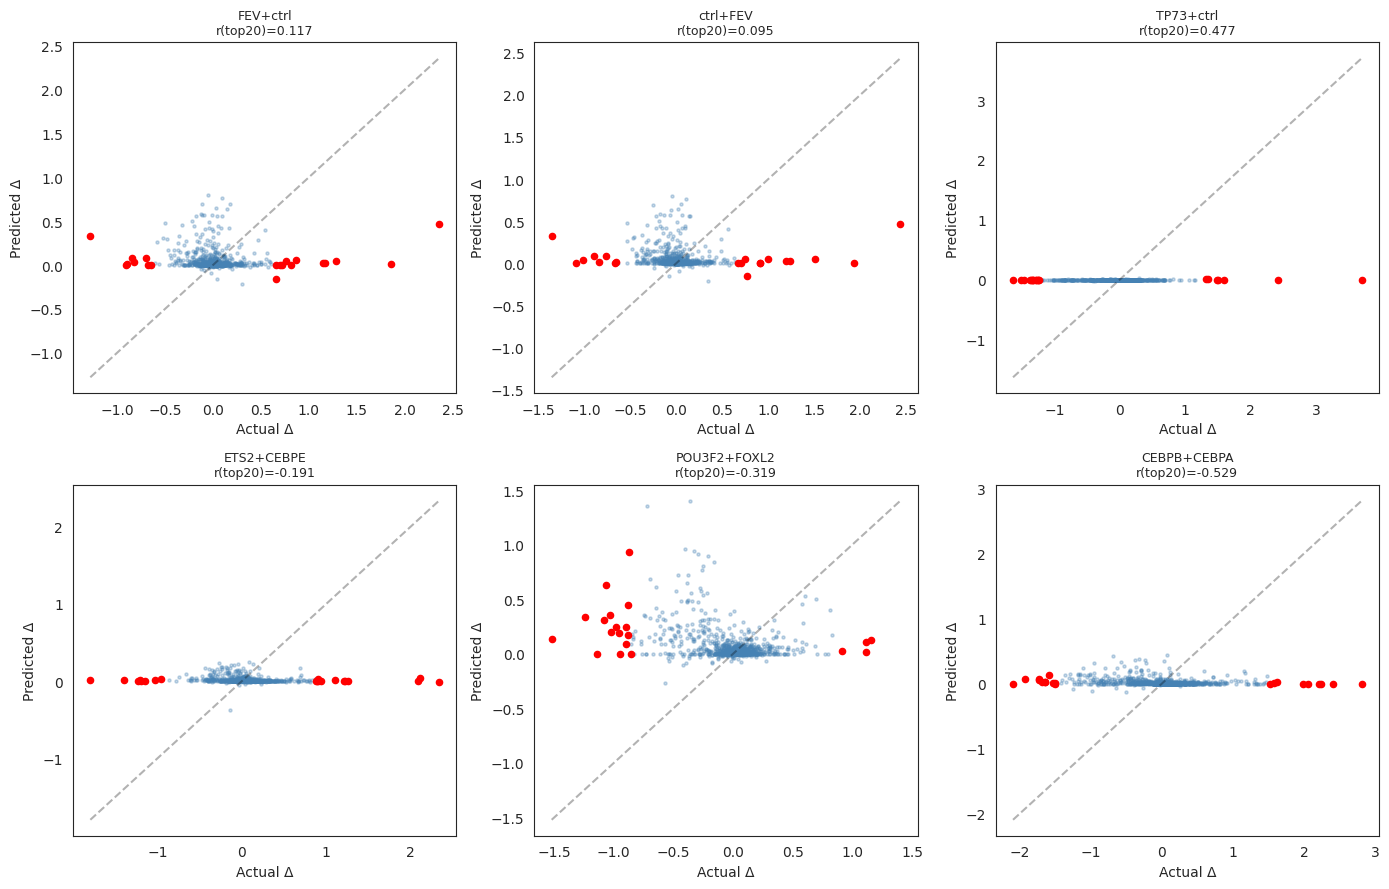

Saved: celloracle_eval_scatter.png


In [21]:
# 7.1 Scatter: predicted vs actual delta for a few conditions
n_show = min(6, len(co_deltas))
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

for i, cond in enumerate(list(co_deltas.keys())[:n_show]):
    ax = axes[i]
    pred = co_deltas[cond][eval_oracle_idx]
    gt   = gt_deltas[cond][eval_shared_idx]
    
    ax.scatter(gt, pred, alpha=0.3, s=5, c='steelblue')
    
    # Highlight top 20
    abs_gt = np.abs(gt)
    top20 = np.argsort(abs_gt)[::-1][:20]
    ax.scatter(gt[top20], pred[top20], c='red', s=20, zorder=5, label='top20 DE')
    
    # Diagonal
    lims = [min(gt.min(), pred.min()), max(gt.max(), pred.max())]
    ax.plot(lims, lims, 'k--', alpha=0.3)
    
    r_val = df_results.loc[df_results['condition']==cond, 'pearson_top20'].values[0]
    ax.set_title(f"{cond}\nr(top20)={r_val:.3f}", fontsize=9)
    ax.set_xlabel('Actual Δ')
    ax.set_ylabel('Predicted Δ')

for j in range(n_show, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('celloracle_eval_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: celloracle_eval_scatter.png")

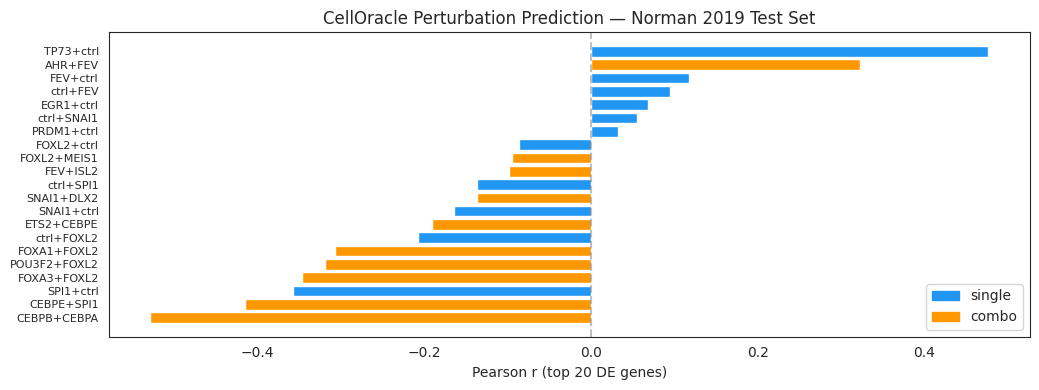

In [22]:
# 7.2 Bar plot of Pearson r per condition
fig, ax = plt.subplots(figsize=(max(8, len(df_results)*0.5), 4))
df_sorted = df_results.sort_values('pearson_top20', ascending=True)
colors = ['#2196F3' if t == 'single' else '#FF9800' for t in df_sorted['type']]
ax.barh(range(len(df_sorted)), df_sorted['pearson_top20'], color=colors)
ax.set_yticks(range(len(df_sorted)))
ax.set_yticklabels(df_sorted['condition'], fontsize=8)
ax.set_xlabel('Pearson r (top 20 DE genes)')
ax.set_title('CellOracle Perturbation Prediction — Norman 2019 Test Set')
ax.axvline(0, c='grey', ls='--', alpha=0.5)

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#2196F3', label='single'), Patch(color='#FF9800', label='combo')],
          loc='lower right')

plt.tight_layout()
plt.savefig('celloracle_eval_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# 8. Save results
df_results.to_csv('celloracle_eval_results_norman2019.csv', index=False)
print("Saved: celloracle_eval_results_norman2019.csv")
print(f"\nTotal conditions evaluated: {len(df_results)}")
print(f"Coverage: {len(df_results)} / {len([c for c in test_conditions if c != 'ctrl'])} test conditions")
print(f"\nNote: CellOracle can only simulate perturbations of genes that are")
print(f"TFs in its GRN. {len(test_not_simulatable)} test conditions were skipped")
print(f"because at least one perturbed gene is not a GRN TF.")
print(f"For the final benchmark table, report CellOracle metrics ONLY on")
print(f"the {len(df_results)} simulatable conditions, or report 'N/A' for others.")

Saved: celloracle_eval_results_norman2019.csv

Total conditions evaluated: 21
Coverage: 21 / 114 test conditions

Note: CellOracle can only simulate perturbations of genes that are
TFs in its GRN. 93 test conditions were skipped
because at least one perturbed gene is not a GRN TF.
For the final benchmark table, report CellOracle metrics ONLY on
the 21 simulatable conditions, or report 'N/A' for others.


## Notes for benchmark integration

**Fair comparison strategy:**
1. **Primary table:** Compare all baselines on the FULL GEARS test set (GEARS/scGPT cover all conditions). CellOracle gets N/A for conditions with non-TF perturbations.
2. **Secondary table:** Compare all baselines on the **CellOracle-simulatable subset** only — this is the fair head-to-head.
3. **Report coverage** alongside metrics: CellOracle covers only 30.4% of perturbed genes.

**Why this is valid:** CellOracle never saw perturbation outcomes. The GRN was built from ctrl cells only. GEARS/scGPT are trained on the train split perturbation data. Different information regimes — that's exactly what the benchmark should expose.

**Sensitivity analysis (optional):** Vary the OE target value (90th/95th/99th percentile, max, or 2x/3x/5x mean) and report how sensitive predictions are to this choice.